# Trajectory Evaluation
This notebook presents the analysis of the scored trajectories.

In [300]:
# import dependencies
import numpy as np
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()

In [193]:
# data import

single_path = DATA/"single_scored.csv"

multi_path = DATA/"multi_scored.csv"

multiV_path = DATA/"multi_verifier_scored.csv"

single_df = pd.read_csv(single_path, encoding = "utf-8", sep = ";")

multi_df = pd.read_csv(multi_path, encoding = "utf-8", sep = ";")

multiV_df = pd.read_csv(multiV_path, encoding = "utf-8", sep = ";")


In [394]:
# preview the dataframes

(print(single_df.shape))
single_df.head()

(print(multi_df.shape))
multi_df.head()

(print(multiV_df.shape))
multiV_df.head()


(339, 22)
(339, 21)
(339, 21)


,turn,trajectory_id,ablation_mode,student_input,final_response,problem_solved,reflection_count,next_agent,emotion,verif_parseable,...,verif_answer,orchestrator_instruction,error_detection,math_guidance,premature_answer,state_regression,meta_timing,session_closed,notes,student
0,1,average_01_run1,single,How can I solve the following question 8 - 2 *...,"To solve this expression correctly, which oper...",False,0,SingleAgent,neutral,NaN,...,NaN,NaN,NaN,correct,no,no,late,no,NaN,average
1,2,average_01_run1,single,"I start from the left, 8 - 2 = 6, then multiply","Actually, the order of operations requires you...",False,0,SingleAgent,neutral,NaN,...,NaN,NaN,hit,correct,no,no,late,no,NaN,average
2,3,average_01_run1,single,Why it’s not correct?,The issue is that multiplication has higher pr...,False,0,SingleAgent,neutral,NaN,...,NaN,NaN,NaN,partial,no,no,late,no,NaN,average
3,4,average_01_run1,single,You mean to start from the multiplication? In ...,"Good, you have correctly identified that 2 * 3...",False,0,SingleAgent,neutral,NaN,...,NaN,NaN,NaN,correct,no,no,late,no,NaN,average
4,5,average_01_run1,single,"So then from left to right, meaning 8 - 6 first","Yes, once you have simplified the multiplicati...",False,0,SingleAgent,neutral,NaN,...,NaN,NaN,NaN,correct,no,no,late,no,NaN,average


## Error detection 

In [67]:
# Error detection with single condition
single_error = single_df["error_detection"].value_counts()
single_error

error_detection
hit               55
false_positive    13
miss              10
Name: count, dtype: int64

In [68]:
# Error detection with multi condition
multi_error = multi_df["error_detection"].value_counts()
multi_error

error_detection
hit               60
false_positive     9
miss               5
Name: count, dtype: int64

In [69]:
# Error detection with multi + verifier condition
multiV_error = multiV_df["error_detection"].value_counts()
multiV_error

error_detection
hit               60
false_positive     7
miss               5
Name: count, dtype: int64

In [392]:
# calculate recall
single_recall = (single_error["hit"]/(single_error["hit"] + single_error["miss"]) * 100).round(2)
multi_recall = (multi_error["hit"]/(multi_error["hit"] + multi_error["miss"]) * 100).round(2)
multiV_recall = (multiV_error["hit"]/(multiV_error["hit"] + multiV_error["miss"]) * 100).round(2)

print(f"Recall (hit / hit + miss) for single condition {single_recall}, multi condition {multi_recall}, multi_verifier condietion {multiV_recall}")

hit_rate_df = pd.DataFrame()
hit_rate_df["condition"] = ["single", "multi", "multi_verifier"]
hit_rate_df["recall"] = [single_recall, multi_recall, multiV_recall]

hit_rate_df.head()


Recall (hit / hit + miss) for single condition 84.62, multi condition 92.31, multi_verifier condietion 92.31


,condition,recall
0,single,84.62
1,multi,92.31
2,multi_verifier,92.31


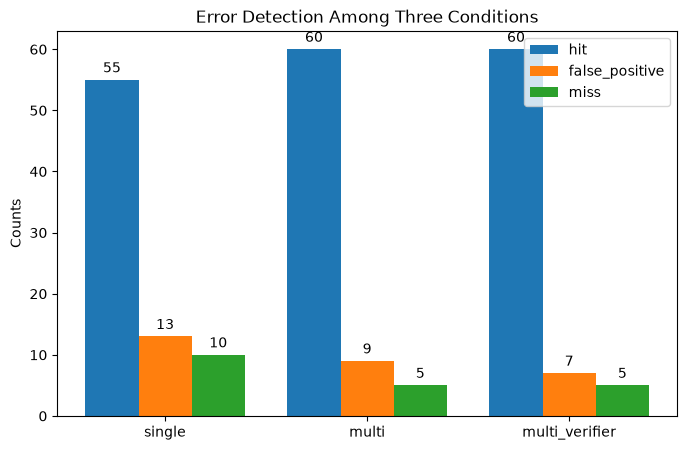

In [412]:
# plotting
error_df = pd.DataFrame()
condition = ["single", "multi", "multi_verifier"]
error_df["hit"] = [single_error["hit"], multi_error["hit"], multiV_error["hit"]]
error_df["false_positive"] = [single_error["false_positive"], multi_error["false_positive"], multiV_error["false_positive"]]
error_df["miss"] = [single_error["miss"], multi_error["miss"], multiV_error["miss"]]

error_df

# grouped bar chart

fig, ax = plt.subplots(figsize = (8, 5))
error_plot = ax.grouped_bar(error_df, tick_labels = condition, group_spacing=0.8)
ax.set_title("Error Detection Among Three Conditions")
ax.set_ylabel("Counts")
ax.legend(loc='upper right')
for container in error_plot.bar_containers:
  ax.bar_label(container, padding=3)
    
plt.savefig('error_detection.png', dpi=300)


## Math Guidance

In [72]:
# Math guidance single condition
single_guidance = single_df["math_guidance"].value_counts()
single_guidance

math_guidance
correct      274
partial       41
incorrect     24
Name: count, dtype: int64

In [73]:
# Math guidance muliti condition
multi_guidance = multi_df["math_guidance"].value_counts()
multi_guidance

math_guidance
correct      310
partial       26
incorrect      3
Name: count, dtype: int64

In [74]:
# Math guidance multi_verifier condition
multiV_guidance = multiV_df["math_guidance"].value_counts()
multiV_guidance

math_guidance
correct      313
partial       23
incorrect      3
Name: count, dtype: int64

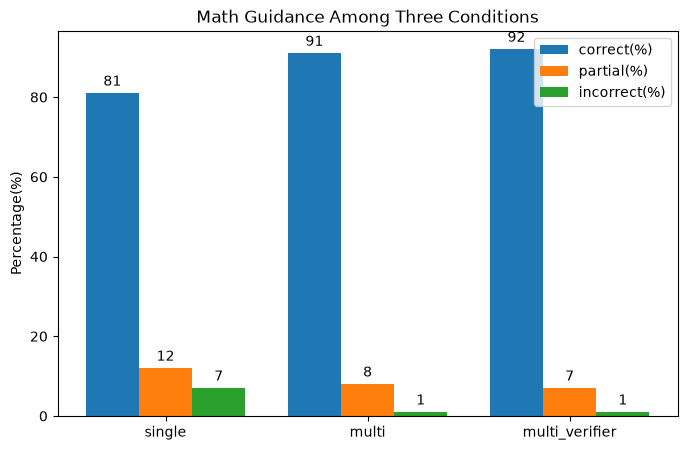

In [413]:
# plotting
guidance_df = pd.DataFrame()
guidance_df["correct"] = [single_guidance["correct"], multi_guidance["correct"], multiV_guidance["correct"]]
guidance_df["partial"] = [single_guidance["partial"], multi_guidance["partial"], multiV_guidance["partial"]]
guidance_df["incorrect"] =[single_guidance["incorrect"], multi_guidance["incorrect"], multiV_guidance["incorrect"]]

# convert to percentage before plotting
guidance_df["correct(%)"] = (guidance_df[["correct"]]/len(single_df)).round(2) * 100
guidance_df["partial(%)"] = (guidance_df[["partial"]]/len(single_df)).round(2) * 100
guidance_df["incorrect(%)"] = (guidance_df[["incorrect"]]/len(single_df)).round(2) * 100

guidance_df_pct = guidance_df[["correct(%)", "partial(%)", "incorrect(%)"]]

# grouped bar chart
fig, ax = plt.subplots(figsize = (8, 5))
guidance_plot = ax.grouped_bar(guidance_df_pct, tick_labels = condition, group_spacing=0.8)
ax.set_title("Math Guidance Among Three Conditions")
ax.set_ylabel("Percentage(%)")
ax.legend(loc='upper right')
for container in guidance_plot.bar_containers:
  ax.bar_label(container, padding=3)

plt.savefig('math_guidance.png', dpi=300)


In [227]:
# guidance % correct dataframe --> for mearging
guid_correct_df = pd.DataFrame()
guid_correct_df["condition"] = ["single", "multi", "multi_verifier"]
guid_correct_df["correct(%)"] = guidance_df["correct(%)"]

guid_correct_df


,condition,correct(%)
0,single,81.0
1,multi,91.0
2,multi_verifier,92.0


## Premature_answer

In [204]:
# trajectory-wise analysis
# single condition

single_premature_t = pd.DataFrame(single_df.groupby("trajectory_id")["premature_answer"].apply(lambda x: x.eq('yes').any().astype(int)))

single_premature_t.head()


,premature_answer
trajectory_id,
average_01_run1,0
average_02_run1,0
average_03_run1,0
average_04_run1,0
average_05_run1,0


In [206]:
# multi condition
multi_premature_t = pd.DataFrame(multi_df.groupby("trajectory_id")["premature_answer"].apply(lambda x: x.eq('yes').any().astype(int)))

multi_premature_t.head()


,premature_answer
trajectory_id,
average_01_run1,1
average_02_run1,0
average_03_run1,0
average_04_run1,0
average_05_run1,0


In [209]:
# multi_verifier condition
multiV_premature_t = pd.DataFrame(multiV_df.groupby("trajectory_id")["premature_answer"].apply(lambda x: x.eq('yes').any().astype(int)))

multiV_premature_t.head()


,premature_answer
trajectory_id,
average_01_run1,1
average_02_run1,0
average_03_run1,0
average_04_run1,0
average_05_run1,0


In [397]:
# Dataframe setup
premature_t_df = pd.DataFrame()
premature_t_df["condition"] = ["single", "multi", "multi_verifier"]
premature_t_df["prema_trajectory_count"] = [single_premature_t["premature_answer"].sum(), multi_premature_t["premature_answer"].sum(), multiV_premature_t["premature_answer"].sum()]

premature_t_df


,condition,prema_trajectory_count
0,single,0
1,multi,5
2,multi_verifier,8


In [76]:
# Turn-wise analysis
# Premature answer single condition
single_premature = single_df["premature_answer"].value_counts()

single_premature


premature_answer
no    339
Name: count, dtype: int64

In [77]:
# Premature answer multi condition
multi_premature = multi_df["premature_answer"].value_counts()

multi_premature


premature_answer
no     332
yes      7
Name: count, dtype: int64

In [78]:
# Premature answer multi_verification condition
multiV_premature = multiV_df["premature_answer"].value_counts()

multiV_premature


premature_answer
no     328
yes     11
Name: count, dtype: int64

/var/folders/7g/bwpnwk3s5f7_5bt2sbx63xp40000gn/T/ipykernel_22633/2056384278.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


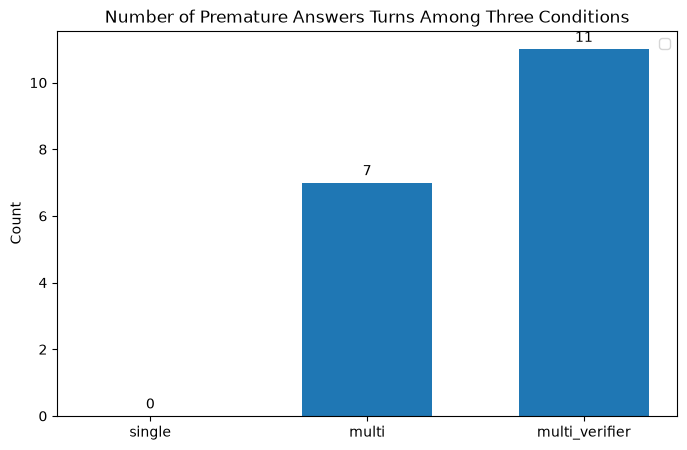

In [415]:
# plotting
premature_df = pd.DataFrame()
premature_df["condition"] = ["single", "multi", "multi_verifier"]
premature_df["yes"] = [0, multi_premature["yes"], multiV_premature["yes"]]

premature_df

# bar chart
fig, ax = plt.subplots(figsize = (8, 5))
premature_plot = ax.bar(premature_df["condition"], premature_df["yes"], width=0.6)
ax.set_title("Number of Premature Answers Turns Among Three Conditions")
ax.set_ylabel("Count")
ax.legend(loc='upper right')
for container in ax.containers:
  ax.bar_label(container, padding=3)

plt.savefig('premature_turns.png', dpi=300)


## State regression

In [211]:
# trajectory-wise analysis
# single condition

single_regression_t = pd.DataFrame(single_df.groupby("trajectory_id")["state_regression"].apply(lambda x: x.eq('yes').any().astype(int)))

single_regression_t.head()


,state_regression
trajectory_id,
average_01_run1,0
average_02_run1,0
average_03_run1,0
average_04_run1,1
average_05_run1,0


In [213]:
# multi condition

multi_regression_t = pd.DataFrame(multi_df.groupby("trajectory_id")["state_regression"].apply(lambda x: x.eq('yes').any().astype(int)))

multi_regression_t.head()



,state_regression
trajectory_id,
average_01_run1,0
average_02_run1,0
average_03_run1,0
average_04_run1,0
average_05_run1,0


In [215]:
# multi_verifier condition

multiV_regression_t = pd.DataFrame(multiV_df.groupby("trajectory_id")["state_regression"].apply(lambda x: x.eq('yes').any().astype(int)))

multiV_regression_t.head()


,state_regression
trajectory_id,
average_01_run1,0
average_02_run1,0
average_03_run1,1
average_04_run1,0
average_05_run1,0


In [398]:
# Dataframe setup
regression_t_df = pd.DataFrame()
regression_t_df["condition"] = ["single", "multi", "multi_verifier"]
regression_t_df["reg_trajectory_count"] = [single_regression_t["state_regression"].sum(), multi_regression_t["state_regression"].sum(), multiV_regression_t["state_regression"].sum()]

regression_t_df


,condition,reg_trajectory_count
0,single,9
1,multi,14
2,multi_verifier,13


In [80]:
# turn-wi
# State regression single condition
single_regression = single_df["state_regression"].value_counts()

single_regression

state_regression
no     316
yes     23
Name: count, dtype: int64

In [81]:
# State regression multi condition
multi_regression = multi_df["state_regression"].value_counts()

multi_regression

state_regression
no     304
yes     35
Name: count, dtype: int64

In [82]:
# State regression multi_verifier condition
multiV_regression = multiV_df["state_regression"].value_counts()

multiV_regression

state_regression
no     304
yes     35
Name: count, dtype: int64

/var/folders/7g/bwpnwk3s5f7_5bt2sbx63xp40000gn/T/ipykernel_22633/2935041213.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


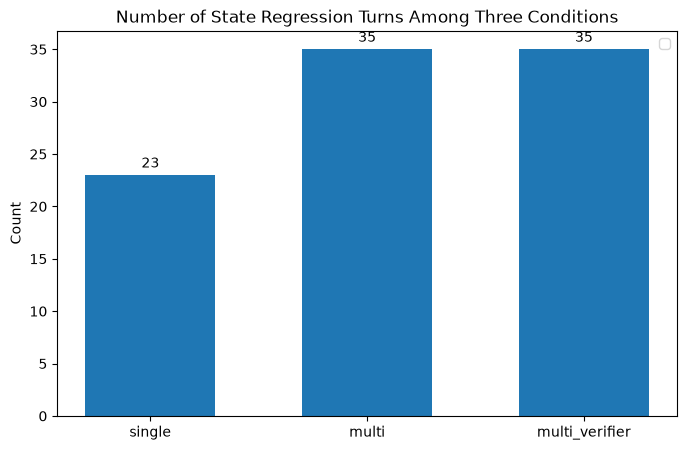

In [416]:
# plotting
regression_df = pd.DataFrame()
regression_df["condition"] = ["single", "multi", "multi_verifier"]
regression_df["yes"] = [single_regression["yes"], multi_regression["yes"], multiV_regression["yes"]]

regression_df

# bar chart
fig, ax = plt.subplots(figsize = (8, 5))
premature_plot = ax.bar(regression_df["condition"], regression_df["yes"], width=0.6)
ax.set_title("Number of State Regression Turns Among Three Conditions")
ax.set_ylabel("Count")
ax.legend(loc='upper right')
for container in ax.containers:
  ax.bar_label(container, padding=3)

plt.savefig('regression_turns.png', dpi=300)


## Meta Timing

In [288]:
# Meta timing single condition
single_meta = pd.DataFrame(single_df.groupby("trajectory_id")["meta_timing"].agg(lambda x: x.mode()[0]))
print(single_meta.shape)
single_meta["student"] = single_meta.index.str.split("_").str[0]

print(pd.crosstab(single_meta['meta_timing'], single_meta['student']))

# count values
single_meta_count = single_meta["meta_timing"].value_counts()
single_meta_count


(30, 1)
student      average  strong  struggle
meta_timing                           
early              0       0         1
late               4       3         3
missing            6       7         6


meta_timing
missing    19
late       10
early       1
Name: count, dtype: int64

In [399]:
# Meta timing multi condition
multi_meta = pd.DataFrame(multi_df.groupby("trajectory_id")["meta_timing"].agg(lambda x: x.mode()[0]))
multi_meta["student"] = multi_meta.index.str.split("_").str[0]

print(pd.crosstab(multi_meta['meta_timing'], multi_meta['student']))

# count values
multi_meta_count = multi_meta["meta_timing"].value_counts()
multi_meta_count


student      average  strong  struggle
meta_timing                           
late               1       4         0
missing            4       4         7
ok                 5       2         3


meta_timing
missing    15
ok         10
late        5
Name: count, dtype: int64

In [290]:
# Meta timing multi_verifier condition
multiV_meta = pd.DataFrame(multiV_df.groupby("trajectory_id")["meta_timing"].agg(lambda x: x.mode()[0]))
multiV_meta["student"] = multiV_meta.index.str.split("_").str[0]

print(pd.crosstab(multiV_meta['meta_timing'], multiV_meta['student']))

# count values
multiV_meta_count = multiV_meta["meta_timing"].value_counts()
multiV_meta_count


student      average  strong  struggle
meta_timing                           
late               2       3         2
missing            4       3         7
ok                 4       4         1


meta_timing
missing    14
ok          9
late        7
Name: count, dtype: int64

## Session closed

In [291]:
# Session closed single condition
single_close = pd.DataFrame(single_df.groupby("trajectory_id")["session_closed"].agg(lambda x: x.mode()[0]))
single_close["student"] = single_close.index.str.split("_").str[0]

print(pd.crosstab(single_close['session_closed'], single_close['student']))

# count values
single_close_count = single_close["session_closed"].value_counts()
single_close_count


student         average  strong  struggle
session_closed                           
no                   10      10        10


session_closed
no    30
Name: count, dtype: int64

In [293]:
# Session closed multi condition
multi_close = pd.DataFrame(multi_df.groupby("trajectory_id")["session_closed"].agg(lambda x: x.mode()[0]))
multi_close["student"] = multi_close.index.str.split("_").str[0]

print(pd.crosstab(multi_close['session_closed'], multi_close['student']))

# count values
multi_close_count = multi_close["session_closed"].value_counts()
multi_close_count


student         average  strong  struggle
session_closed                           
no                    6       8         8
yes                   4       2         2


session_closed
no     22
yes     8
Name: count, dtype: int64

In [294]:
# Session closed multi_verifier condition
multiV_close = pd.DataFrame(multiV_df.groupby("trajectory_id")["session_closed"].agg(lambda x: x.mode()[0]))
multiV_close["student"] = multiV_close.index.str.split("_").str[0]

print(pd.crosstab(multiV_close['session_closed'], multiV_close['student']))

# count values
multiV_close_count = multiV_close["session_closed"].value_counts()
multiV_close_count


student         average  strong  struggle
session_closed                           
no                    6       6         9
yes                   4       4         1


session_closed
no     21
yes     9
Name: count, dtype: int64

## Overview table

In [409]:
# merge existing outputs
overview_df = hit_rate_df.merge(guid_correct_df, on = "condition", 
                                how = "left").merge(premature_t_df, 
                                                    on = "condition", how = "left").merge(regression_t_df, 
                                                                                          on = "condition", how = "left")
overview_df = overview_df.rename(columns = {"correct(%)" : "guidance %",
                                           "prema_trajectory_count" : "premature any-yes",
                                           "reg_trajectory_count" : "regression any-yes",})


overview_df

,condition,recall,guidance %,premature any-yes,regression any-yes
0,single,84.62,81.0,0,9
1,multi,92.31,91.0,5,14
2,multi_verifier,92.31,92.0,8,13


In [410]:
overview_df["meta_ok"] = [0, multi_meta_count["ok"], multiV_meta_count["ok"]]
overview_df["closed"] = [0, multi_close_count["yes"], multiV_close_count["yes"]]

overview_df

,condition,recall,guidance %,premature any-yes,regression any-yes,meta_ok,closed
0,single,84.62,81.0,0,9,0,0
1,multi,92.31,91.0,5,14,10,8
2,multi_verifier,92.31,92.0,8,13,9,9


In [411]:
# present as fractions
overview_df["premature any-yes"] = [str(x) + "/30" for x in overview_df["premature any-yes"]]
overview_df["regression any-yes"] = [str(x) + "/30" for x in overview_df["regression any-yes"]]
overview_df["meta_ok"] = [str(x) + "/30" for x in overview_df["meta_ok"]]
overview_df["closed"] = [str(x) + "/30" for x in overview_df["closed"]]

overview_df

,condition,recall,guidance %,premature any-yes,regression any-yes,meta_ok,closed
0,single,84.62,81.0,0/30,9/30,0/30,0/30
1,multi,92.31,91.0,5/30,14/30,10/30,8/30
2,multi_verifier,92.31,92.0,8/30,13/30,9/30,9/30


## Disagreement appendix

In [299]:
# import data
disagree_path = DATA/"disagreement.csv"
disagree_df = pd.read_csv(disagree_path, encoding = "utf-8", sep = ";")

disagree_df.head()

,turn,trajectory_id,ablation_mode,student_input,final_response,problem_solved,reflection_count,next_agent,emotion,verif_parseable,...,verif_problem_solved,verif_answer,orchestrator_instruction,error_detection,math_guidance,premature_answer,state_regression,meta_timing,session_closed,notes
0,1,strong_07_run2,multi,How can I simplify (1 + 1/2) / (1 - 3/4)?,Try rewriting the whole number 1 as a fraction...,False,0,NaN,confused,False,...,False,NaN,Let's start by simplifying the numerator and t...,NaN,correct,no,no,ok,yes,NaN
1,2,strong_07_run2,multi,1 + 1/2 = 2/2 + 1/2 = 3/2,"You've simplified the top part well, but what ...",False,0,NaN,confused,False,...,False,NaN,You have correctly simplified the numerator to...,NaN,correct,no,no,ok,yes,NaN
2,3,strong_07_run2,multi,Then 1 - 3/4 = 4/4 - 3/4 = 1/4,"You have both parts simplified, but remember t...",False,0,NaN,confused,False,...,False,NaN,You have correctly simplified the numerator to...,NaN,correct,no,no,ok,yes,NaN
3,4,strong_07_run2,multi,"3/2 / 1/4 = 3/2 * 4/1 = 6, the answer is 6",Great job finding the final answer of 6! Can y...,True,1,NaN,confused,False,...,False,NaN,The student has correctly simplified the numer...,NaN,correct,no,no,ok,yes,NaN
4,5,strong_07_run2,multi,"Parentheses first, then rewrite the division a...","You correctly identified the rule, but can you...",True,2,NaN,confused,False,...,False,NaN,The student has correctly solved the problem (...,NaN,correct,no,no,ok,yes,NaN


In [334]:
# check the unique trajectory_id
traj_id = pd.Series(disagree_df["trajectory_id"].unique())
ablation = pd.Series(disagree_df["ablation_mode"].unique())

print(traj_id)
print(ablation)

0     strong_07_run2
1    average_07_run2
dtype: str
0             multi
1    multi_verifier
dtype: str


In [383]:
# strip the traj_id to match the run1 table
persona = traj_id.str.split("_").str[0]
number = traj_id.str.split("_").str[1]

id1 = persona[0] + "_" + number[0]
id2 = persona[1] + "_" + number[1]


In [384]:
# select the same trajectories from the run1 
run1_multi = multi_df[multi_df["trajectory_id"].str.contains(id1)]
run1_multiV = multiV_df[multiV_df["trajectory_id"].str.contains(id2)]

run2_multi = disagree_df[disagree_df["ablation_mode"] == ablation[0]]
run2_multiV = disagree_df[disagree_df["ablation_mode"] == ablation[1]]


In [385]:
# compare the first table
# problem_solved
solved_multi1 = run1_multi[run1_multi["problem_solved"] == True]
solved_multi2 = run2_multi[run2_multi["problem_solved"] == True]

turn_multi1 = solved_multi1["turn"].iloc[0]
turn_multi2 = solved_multi2["turn"].iloc[0]

print(f"{id1} run1 solve turn {turn_multi1}, run2 solve turn {turn_multi2}")

# meta_timing
meta_multi1 = run1_multi["meta_timing"].agg(lambda x: x.mode()[0])

meta_multi2 = run2_multi["meta_timing"].agg(lambda x: x.mode()[0])

print(f"{id1} run1 meta timing {meta_multi1}, run2 meta timing {meta_multi2}")

# session_closed
close_multi1 = run1_multi["session_closed"].agg(lambda x: x.mode()[0])

close_multi2 = run2_multi["session_closed"].agg(lambda x: x.mode()[0])

print(f"{id1} run1 session close {close_multi1}, run2 session close {close_multi2}")



strong_07 run1 solve turn 6, run2 solve turn 4
strong_07 run1 meta timing late, run2 meta timing ok
strong_07 run1 session close no, run2 session close yes


In [374]:
# compare the second table
# problem_solved
solved_multiV1 = run1_multiV[run1_multiV["problem_solved"] == True]
solved_multiV2 = [x if x == True else "NOT SOLVED" for x in run2_multiV["problem_solved"]]


turn_multiV1 = solved_multiV1["turn"].iloc[0]
turn_multiV2 = solved_multiV2[0]

print(f"{id2} run1 solve turn {turn_multiV1}, run2 {turn_multiV2}")

# meta_timing
meta_multiV1 = run1_multiV["meta_timing"].agg(lambda x: x.mode()[0])

meta_multiV2 = run2_multiV["meta_timing"].agg(lambda x: x.mode()[0])

print(f"{id2} run1 meta timing {meta_multiV1}, run2 meta timing {meta_multiV2}")

# session_closed
close_multiV1 = run1_multiV["session_closed"].agg(lambda x: x.mode()[0])

close_multiV2 = run2_multiV["session_closed"].agg(lambda x: x.mode()[0])

print(f"{id2} run1 session close {close_multiV1}, run2 session close {close_multiV2}")


average_07 run1 solve turn 9, run2 NOT SOLVED
average_07 run1 meta timing late, run2 meta timing missing
average_07 run1 session close no, run2 session close no


In [396]:
# appendix table
appendix_df = pd.DataFrame()
appendix_df["trajectory"] = [id1, id2]
appendix_df["condition"] = ablation
appendix_df["what differed"] = ["solve_turn, meta_timing, session_close", "solve_turn, meta_timing"]
appendix_df["run1"] = ["T6 / late / no", "T9 / late / no"]
appendix_df["run2"] = ["T4 / ok / yes", "never / missing / no"]

appendix_df

,trajectory,condition,what differed,run1,run2
0,strong_07,multi,"solve_turn, meta_timing, session_close",T6 / late / no,T4 / ok / yes
1,average_07,multi_verifier,"solve_turn, meta_timing",T9 / late / no,never / missing / no
